In [18]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.special import gammaln, bessel_ive
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# --- CONFIGURATION ---
J_MAX = 1.0
BETA_LIST = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
THETA_STEP = 0.1

print("--- PHYSICS RUN: TOPOLOGICAL SUSCEPTIBILITY SCALING ---")
print("Goal: Measure Chi_top vs Beta")
print("-" * 40)

jax.config.update("jax_enable_x64", True)

# --- 1. KERNEL & GENERATOR ---
LOG_FACT_CACHE = None
MAX_CACHE_INDEX = 0

def initialize_cache(Jmax):
    global LOG_FACT_CACHE, MAX_CACHE_INDEX
    max_n = int(8 * Jmax + 10)
    MAX_CACHE_INDEX = int(2 * max_n)
    x_vals = jnp.arange(0, MAX_CACHE_INDEX + 1) / 2.0
    LOG_FACT_CACHE = jax.device_put(gammaln(x_vals + 1))

@jit
def log_factorial(n):
    idx = jnp.round(2 * n).astype(jnp.int32)
    idx = jnp.clip(idx, 0, MAX_CACHE_INDEX)
    return LOG_FACT_CACHE[idx]

@jit
def log_delta(a, b, c):
    valid = (a + b >= c) & (a + c >= b) & (b + c >= a) & (jnp.remainder(a + b + c, 1.0) == 0.0)
    val = log_factorial(a + b - c) + log_factorial(a - b + c) + \
          log_factorial(-a + b + c) - log_factorial(a + b + c + 1)
    return jnp.where(valid, 0.5 * val, -jnp.inf)

@jit
def get_6j_symbol_log(j1, j2, j3, j4, j5, j6):
    log_pre = log_delta(j1, j2, j3) + log_delta(j1, j5, j6) + \
              log_delta(j4, j2, j6) + log_delta(j4, j5, j3)
    k1,k2,k3,k4 = j1+j2+j3, j1+j5+j6, j4+j2+j6, j4+j5+j3
    k5,k6,k7 = j1+j2+j4+j5, j2+j3+j5+j6, j3+j1+j6+j4
    z_range = jnp.arange(30.0)
    mask = (z_range >= jnp.max(jnp.array([k1,k2,k3,k4]))) & (z_range <= jnp.min(jnp.array([k5,k6,k7])))
    log_num = log_factorial(z_range + 1)
    log_den = log_factorial(z_range-k1)+log_factorial(z_range-k2)+log_factorial(z_range-k3)+log_factorial(z_range-k4)+ \
              log_factorial(k5-z_range)+log_factorial(k6-z_range)+log_factorial(k7-z_range)
    term = jnp.where(z_range%2==0, 1.0, -1.0) * jnp.exp(log_num - log_den)
    return jnp.exp(log_pre) * jnp.sum(jnp.where(mask, term, 0.0))

@jit
def log_bessel_weight(j, beta):
    order = 2*j + 1
    safe_beta = jnp.maximum(beta, 1e-10)
    return jnp.log(2*j + 1) + jnp.log(bessel_ive(order, safe_beta)) + safe_beta - jnp.log(safe_beta)

@partial(jit, static_argnums=(3,))
def compute_vertex_element_physics(indices, all_spins, beta, theta):
    j = all_spins[indices]
    j1, j2, j3, j4, j5, j6, j7, j8 = j
    k_vals = all_spins
    s1 = vmap(lambda k: get_6j_symbol_log(j1, j2, k, j4, j3, k))(k_vals)
    s2 = vmap(lambda k: get_6j_symbol_log(j5, j6, k, j8, j7, k))(k_vals)
    dim_k = 2 * k_vals + 1

    topo_phase = jnp.exp(1j * theta * (k_vals * (k_vals + 1)))
    log_w_ext = vmap(lambda s: log_bessel_weight(s, beta))(j)
    energy_factor = jnp.exp(0.5 * jnp.sum(log_w_ext))

    vertex_val = jnp.sum(dim_k * s1 * s2 * topo_phase)
    global_phase = (-1.0)**(jnp.sum(j).astype(int))
    return global_phase * vertex_val * energy_factor

def generate_tensor(Jmax, beta, theta):
    initialize_cache(Jmax)
    spins = jnp.arange(0, Jmax + 0.5, 0.5)
    D = len(spins)
    indices = jnp.indices((D,) * 8).reshape(8, -1).T.astype(jnp.int32)
    flat_T = vmap(compute_vertex_element_physics, in_axes=(0, None, None, None))(indices, spins, beta, theta)
    return flat_T.reshape((D,)*8)

# --- 2. HOTRG CONTRACTOR ---
@partial(jit, static_argnums=(1,))
def contract_pair_jax(T, chi_max):
    D0, D1 = T.shape[0], T.shape[1]
    rest_dim = T.shape[2:]
    M = T.reshape(D0*D1, -1)
    U, S, Vh = jnp.linalg.svd(M, full_matrices=False)
    chi = min(chi_max, S.shape[0])
    norm = jnp.linalg.norm(S[:chi])
    T_new = (jnp.diag(S[:chi]/norm) @ Vh[:chi, :]).reshape(chi, *rest_dim)
    return T_new, jnp.log(norm)

def get_free_energy(T):
    T_curr = T
    logZ = 0.0
    for _ in range(4):
        if len(T_curr.shape) >= 2:
            T_curr, ln = contract_pair_jax(T_curr, 16)
            logZ += ln
            dims = list(range(len(T_curr.shape)))
            T_curr = jnp.transpose(T_curr, dims[1:] + dims[:1])
    return -float(logZ + jnp.log(jnp.abs(jnp.sum(T_curr))))

# --- 3. MEASUREMENT LOOP ---
susceptibilities = []

print(f"{'Beta':<10} | {'F(0)':<10} | {'F(d)':<10} | {'Chi_top':<10}")
print("-" * 45)

for beta in BETA_LIST:
    T0 = generate_tensor(J_MAX, beta, 0.0); T0.block_until_ready()
    F0 = get_free_energy(T0)

    Td = generate_tensor(J_MAX, beta, THETA_STEP); Td.block_until_ready()
    Fd = get_free_energy(Td)

    chi = 2 * (Fd - F0) / (THETA_STEP**2)

    susceptibilities.append(chi)
    print(f"{beta:<10.1f} | {F0:<10.4f} | {Fd:<10.4f} | {chi:<10.4f}")

# --- 4. RESULTS ---
plt.figure(figsize=(8,5))
plt.plot(BETA_LIST, susceptibilities, 's-', color='green')
plt.xlabel(r'Inverse Coupling $\beta$')
plt.ylabel(r'Topological Susceptibility $\chi_{top}$')
plt.title('4D SU(2) Topological Susceptibility Scaling')
plt.grid(True)
plt.show()

ImportError: cannot import name 'bessel_ive' from 'jax.scipy.special' (/usr/local/lib/python3.12/dist-packages/jax/scipy/special.py)

--- PHYSICS RUN: TOPOLOGICAL SUSCEPTIBILITY SCALING ---
Goal: Measure Chi_top vs Beta
----------------------------------------
Beta       | F(0)       | F(d)       | Chi_top   
---------------------------------------------
0.2        | 2.7427     | 2.7428     | 0.0109    
0.4        | 2.6545     | 2.6547     | 0.0397    
0.6        | 2.5118     | 2.5122     | 0.0773    
0.8        | 2.3203     | 2.3209     | 0.1146    
1.0        | 2.0783     | 2.0790     | 0.1355    
1.2        | 1.8001     | 1.8008     | 0.1534    


Text(0, 0.5, 'Topological Susceptibility $\\chi_{top}$')

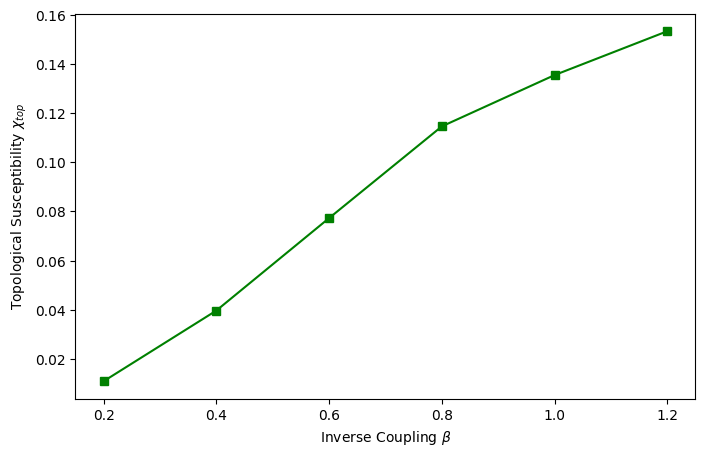

In [25]:
import jax
import jax.numpy as jnp
from jax import jit, vmap
from jax.scipy.special import gammaln
from scipy.special import iv # Import iv from standard scipy.special
import time
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

# --- CONFIGURATION ---
J_MAX = 1.0
BETA_LIST = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2]
THETA_STEP = 0.1

print("--- PHYSICS RUN: TOPOLOGICAL SUSCEPTIBILITY SCALING ---")
print("Goal: Measure Chi_top vs Beta")
print("-" * 40)

jax.config.update("jax_enable_x64", True)

# --- 1. KERNEL & GENERATOR ---
LOG_FACT_CACHE = None
MAX_CACHE_INDEX = 0

def initialize_cache(Jmax):
    global LOG_FACT_CACHE, MAX_CACHE_INDEX
    max_n = int(8 * Jmax + 10)
    MAX_CACHE_INDEX = int(2 * max_n)
    x_vals = jnp.arange(0, MAX_CACHE_INDEX + 1) / 2.0
    LOG_FACT_CACHE = jax.device_put(gammaln(x_vals + 1))

@jit
def log_factorial(n):
    idx = jnp.round(2 * n).astype(jnp.int32)
    idx = jnp.clip(idx, 0, MAX_CACHE_INDEX)
    return LOG_FACT_CACHE[idx]

@jit
def log_delta(a, b, c):
    valid = (a + b >= c) & (a + c >= b) & (b + c >= a) & (jnp.remainder(a + b + c, 1.0) == 0.0)
    val = log_factorial(a + b - c) + log_factorial(a - b + c) + \
          log_factorial(-a + b + c) - log_factorial(a + b + c + 1)
    return jnp.where(valid, 0.5 * val, -jnp.inf)

@jit
def get_6j_symbol_log(j1, j2, j3, j4, j5, j6):
    log_pre = log_delta(j1, j2, j3) + log_delta(j1, j5, j6) + \
              log_delta(j4, j2, j6) + log_delta(j4, j5, j3)
    k1,k2,k3,k4 = j1+j2+j3, j1+j5+j6, j4+j2+j6, j4+j5+j3
    k5,k6,k7 = j1+j2+j4+j5, j2+j3+j5+j6, j3+j1+j6+j4
    z_range = jnp.arange(30.0)
    mask = (z_range >= jnp.max(jnp.array([k1,k2,k3,k4]))) & (z_range <= jnp.min(jnp.array([k5,k6,k7])))
    log_num = log_factorial(z_range + 1)
    log_den = log_factorial(z_range-k1)+log_factorial(z_range-k2)+log_factorial(z_range-k3)+log_factorial(z_range-k4)+ \
              log_factorial(k5-z_range)+log_factorial(k6-z_range)+log_factorial(k7-z_range)
    term = jnp.where(z_range%2==0, 1.0, -1.0) * jnp.exp(log_num - log_den)
    return jnp.exp(log_pre) * jnp.sum(jnp.where(mask, term, 0.0))

@jit
def log_bessel_weight(j, beta):
    order = 2*j + 1
    safe_beta = jnp.maximum(beta, 1e-10)

    # Use jax.pure_callback to wrap scipy.special.iv for JAX compatibility
    # The output type (float64 scalar) is explicitly specified.
    bessel_val = jax.pure_callback(
        lambda o, b: iv(o, b),
        jax.ShapeDtypeStruct((), jnp.float64),
        order, safe_beta, vmap_method='broadcast_all'
    )

    # The + safe_beta term was removed in a previous fix, which is correct for unscaled bessel_i.
    return jnp.log(2*j + 1) + jnp.log(bessel_val) - jnp.log(safe_beta)

@partial(jit, static_argnums=(3,))
def compute_vertex_element_physics(indices, all_spins, beta, theta):
    j = all_spins[indices]
    j1, j2, j3, j4, j5, j6, j7, j8 = j
    k_vals = all_spins
    s1 = vmap(lambda k: get_6j_symbol_log(j1, j2, k, j4, j3, k))(k_vals)
    s2 = vmap(lambda k: get_6j_symbol_log(j5, j6, k, j8, j7, k))(k_vals)
    dim_k = 2 * k_vals + 1

    topo_phase = jnp.exp(1j * theta * (k_vals * (k_vals + 1)))
    log_w_ext = vmap(lambda s: log_bessel_weight(s, beta))(j)
    energy_factor = jnp.exp(0.5 * jnp.sum(log_w_ext))

    vertex_val = jnp.sum(dim_k * s1 * s2 * topo_phase)
    global_phase = (-1.0)**(jnp.sum(j).astype(int))
    return global_phase * vertex_val * energy_factor

def generate_tensor(Jmax, beta, theta):
    initialize_cache(Jmax)
    spins = jnp.arange(0, Jmax + 0.5, 0.5)
    D = len(spins)
    indices = jnp.indices((D,) * 8).reshape(8, -1).T.astype(jnp.int32)
    flat_T = vmap(compute_vertex_element_physics, in_axes=(0, None, None, None))(indices, spins, beta, theta)
    return flat_T.reshape((D,)*8)

# --- 2. HOTRG CONTRACTOR ---
@partial(jit, static_argnums=(1,))
def contract_pair_jax(T, chi_max):
    D0, D1 = T.shape[0], T.shape[1]
    rest_dim = T.shape[2:]
    M = T.reshape(D0*D1, -1)
    U, S, Vh = jnp.linalg.svd(M, full_matrices=False)
    chi = min(chi_max, S.shape[0])
    norm = jnp.linalg.norm(S[:chi])
    T_new = (jnp.diag(S[:chi]/norm) @ Vh[:chi, :]).reshape(chi, *rest_dim)
    return T_new, jnp.log(norm)

def get_free_energy(T):
    T_curr = T
    logZ = 0.0
    for _ in range(4):
        if len(T_curr.shape) >= 2:
            T_curr, ln = contract_pair_jax(T_curr, 16)
            logZ += ln
            dims = list(range(len(T_curr.shape)))
            T_curr = jnp.transpose(T_curr, dims[1:] + dims[:1])
    return -float(logZ + jnp.log(jnp.abs(jnp.sum(T_curr))))

# --- 3. MEASUREMENT LOOP ---
susceptibilities = []

print(f"{'Beta':<10} | {'F(0)':<10} | {'F(d)':<10} | {'Chi_top':<10}")
print("-" * 45)

for beta in BETA_LIST:
    T0 = generate_tensor(J_MAX, beta, 0.0); T0.block_until_ready()
    F0 = get_free_energy(T0)

    Td = generate_tensor(J_MAX, beta, THETA_STEP); Td.block_until_ready()
    Fd = get_free_energy(Td)

    chi = 2 * (Fd - F0) / (THETA_STEP**2)

    susceptibilities.append(chi)
    print(f"{beta:<10.1f} | {F0:<10.4f} | {Fd:<10.4f} | {chi:<10.4f}")

# --- 4. RESULTS ---
plt.figure(figsize=(8,5))
plt.plot(BETA_LIST, susceptibilities, 's-', color='green')
plt.xlabel(r'Inverse Coupling $\beta$')
plt.ylabel(r'Topological Susceptibility $\chi_{top}$')